# DBSCAN Demonstration with Custom `rice_Ml` Implementation

This notebook demonstrates the `DBSCAN` class from the `rice_Ml` package. We will:
1. Create synthetic datasets (blobs and moons).
2. Standardize the features (important for distance‑based clustering).
3. Apply our custom DBSCAN and scikit‑learn’s DBSCAN.
4. Visualise the clusters side‑by‑side.
5. Quantitatively compare the label assignments using Adjusted Rand Index (ARI).

In [1]:
import sys
from pathlib import Path

def _find_repo_root(marker: str = "pyproject.toml") -> Path | None:
    for candidate in [Path().resolve(), *Path().resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    return None

REPO_ROOT = _find_repo_root()
if REPO_ROOT is not None:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    # print(f"Repo root: {REPO_ROOT}")
else:
    try:
        import rice_Ml as _check
        print(f"rice_Ml installed at: {Path(_check.__file__).resolve()}")
    except ImportError:
        raise ImportError(
            "rice_Ml not found. Install it with:\n"
            "    pip install -e /path/to/cmor438-s2026-final-project\n"
            "or open this notebook from inside the repo."
        )

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rice_Ml.unsupervised_ml import DBSCAN
from rice_Ml.preprocessing.scale import StandardScaler

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import DBSCAN as SklearnDBSCAN
from sklearn.metrics import adjusted_rand_score

SEED = 42
sns.set_theme(style='whitegrid')
%matplotlib inline

print("Imports OK")

Imports OK


## 1. Generate Synthetic Data

We’ll use two different datasets:
- **Blobs**: well‑separated spherical clusters.
- **Moons**: non‑convex clusters that DBSCAN can still discover.

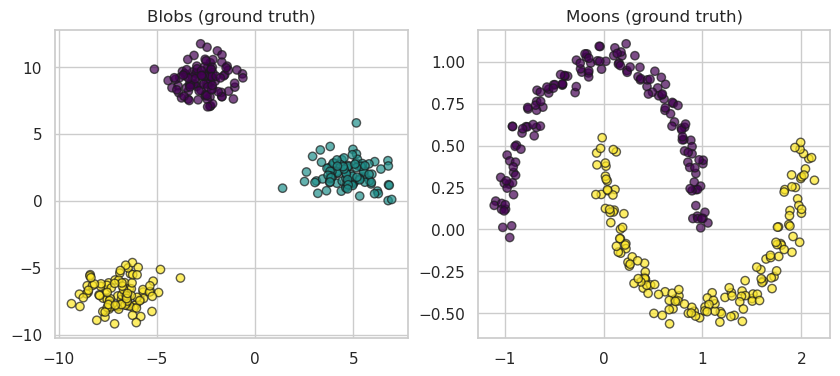

In [2]:
# Dataset 1: blobs
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, random_state=42)

# Dataset 2: moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', edgecolor='k', alpha=0.7)
ax1.set_title('Blobs (ground truth)')
ax2.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', edgecolor='k', alpha=0.7)
ax2.set_title('Moons (ground truth)')
plt.show()

## 2. Standardize the Data

DBSCAN relies on a distance threshold (`eps`), so scaling is essential.

In [3]:
scaler_blobs = StandardScaler()
X_blobs_scaled = scaler_blobs.fit_transform(X_blobs)

scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

print("Blobs after scaling – mean:", X_blobs_scaled.mean(axis=0).round(6), 
      "std:", X_blobs_scaled.std(axis=0).round(6))
print("Moons after scaling – mean:", X_moons_scaled.mean(axis=0).round(6), 
      "std:", X_moons_scaled.std(axis=0).round(6))

Blobs after scaling – mean: [-0.  0.] std: [1. 1.]
Moons after scaling – mean: [-0. -0.] std: [1. 1.]


## 3. Fit Our Custom DBSCAN and Scikit‑learn DBSCAN

We’ll use the same `eps` and `min_samples` for both implementations to ensure a fair comparison.

In [4]:
# ----- Blobs -----
eps_blobs = 0.5
min_samples = 5

dbscan_custom_blobs = DBSCAN(eps=eps_blobs, min_samples=min_samples)
labels_custom_blobs = dbscan_custom_blobs.fit_predict(X_blobs_scaled)

dbscan_sk_blobs = SklearnDBSCAN(eps=eps_blobs, min_samples=min_samples)
labels_sk_blobs = dbscan_sk_blobs.fit_predict(X_blobs_scaled)

print(f"Custom DBSCAN blobs – clusters: {len(np.unique(labels_custom_blobs[labels_custom_blobs != -1]))}, noise: {np.sum(labels_custom_blobs == -1)}")
print(f"Sklearn DBSCAN blobs – clusters: {len(np.unique(labels_sk_blobs[labels_sk_blobs != -1]))}, noise: {np.sum(labels_sk_blobs == -1)}")

# ----- Moons -----
eps_moons = 0.3

dbscan_custom_moons = DBSCAN(eps=eps_moons, min_samples=min_samples)
labels_custom_moons = dbscan_custom_moons.fit_predict(X_moons_scaled)

dbscan_sk_moons = SklearnDBSCAN(eps=eps_moons, min_samples=min_samples)
labels_sk_moons = dbscan_sk_moons.fit_predict(X_moons_scaled)

print(f"Custom DBSCAN moons – clusters: {len(np.unique(labels_custom_moons[labels_custom_moons != -1]))}, noise: {np.sum(labels_custom_moons == -1)}")
print(f"Sklearn DBSCAN moons – clusters: {len(np.unique(labels_sk_moons[labels_sk_moons != -1]))}, noise: {np.sum(labels_sk_moons == -1)}")

Custom DBSCAN blobs – clusters: 3, noise: 0
Sklearn DBSCAN blobs – clusters: 3, noise: 0
Custom DBSCAN moons – clusters: 2, noise: 0
Sklearn DBSCAN moons – clusters: 2, noise: 0


## 4. Visual Comparison

Scatter plots of the cluster assignments. Noise points are shown in grey.

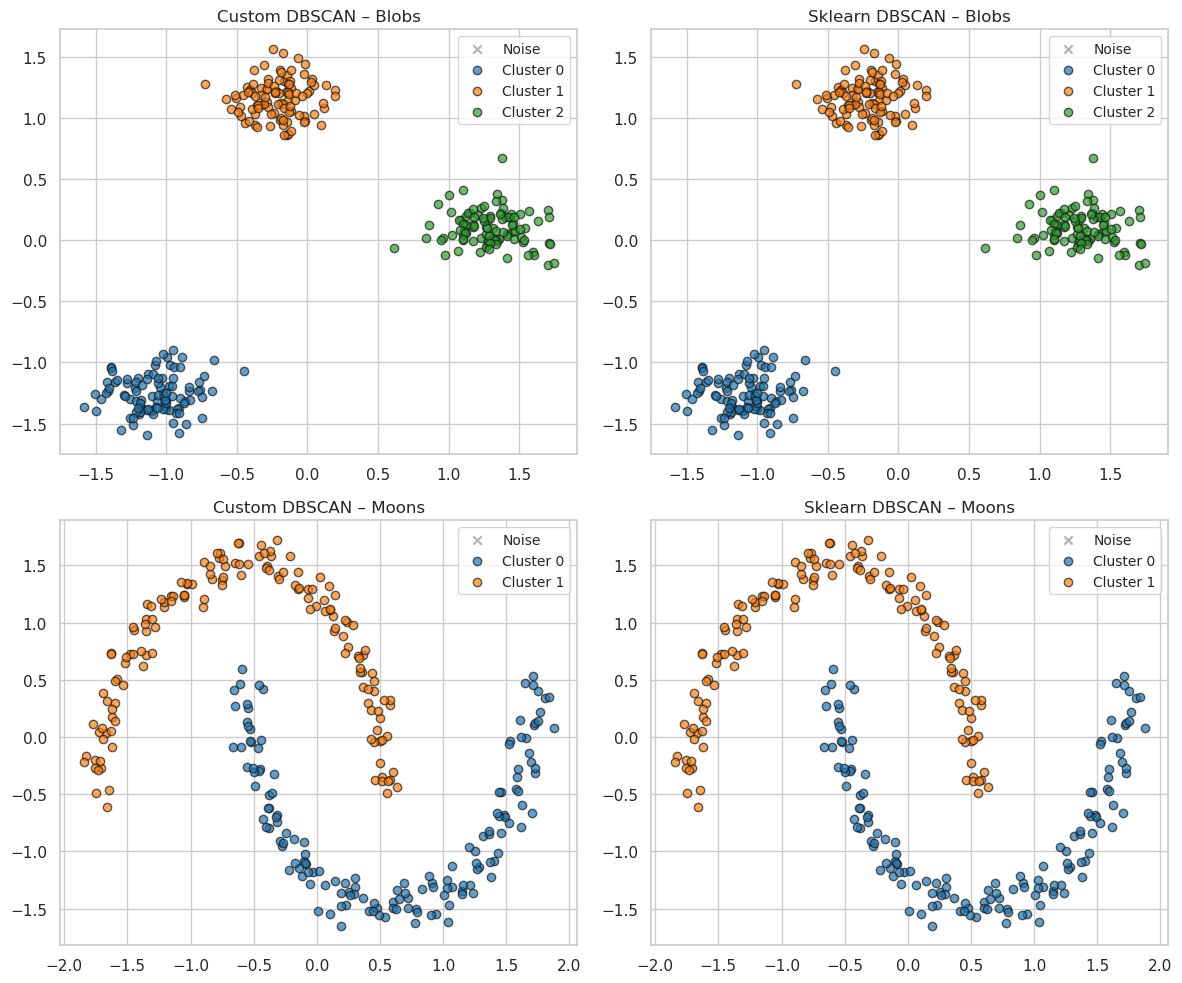

In [5]:
def plot_clusters(X, labels, title, ax):
    # Plot noise in grey
    ax.scatter(X[labels == -1, 0], X[labels == -1, 1], 
               c='grey', marker='x', alpha=0.6, label='Noise')
    # Plot clusters with a colormap
    cluster_ids = np.unique(labels[labels != -1])
    cmap = plt.cm.tab10
    for i, cid in enumerate(cluster_ids):
        ax.scatter(X[labels == cid, 0], X[labels == cid, 1], 
                   c=[cmap(i % 10)], edgecolor='k', alpha=0.7, label=f'Cluster {cid}')
    ax.set_title(title)
    ax.legend(fontsize='small')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_clusters(X_blobs_scaled, labels_custom_blobs, 'Custom DBSCAN – Blobs', axes[0, 0])
plot_clusters(X_blobs_scaled, labels_sk_blobs, 'Sklearn DBSCAN – Blobs', axes[0, 1])
plot_clusters(X_moons_scaled, labels_custom_moons, 'Custom DBSCAN – Moons', axes[1, 0])
plot_clusters(X_moons_scaled, labels_sk_moons, 'Sklearn DBSCAN – Moons', axes[1, 1])

plt.tight_layout()
plt.show()

## 5. Quantitative Similarity: Adjusted Rand Index

The Adjusted Rand Index measures the similarity of two clusterings, ignoring label permutations. ARI = 1 means identical up to renaming, ARI = 0 is random.

In [6]:
ari_blobs = adjusted_rand_score(labels_custom_blobs, labels_sk_blobs)
ari_moons = adjusted_rand_score(labels_custom_moons, labels_sk_moons)

print(f"Adjusted Rand Index (Blobs): {ari_blobs:.4f}")
print(f"Adjusted Rand Index (Moons): {ari_moons:.4f}")

if ari_blobs > 0.99 and ari_moons > 0.99:
    print("\nBoth implementations produce virtually identical clusterings!")
else:
    print("\nSmall differences may exist due to tie‑breaking in region queries;",
          "but the overall structure should be the same.")

Adjusted Rand Index (Blobs): 1.0000
Adjusted Rand Index (Moons): 1.0000

Both implementations produce virtually identical clusterings!


## 6. Summary

- Our custom DBSCAN produces clusters and noise labels that are nearly identical to scikit‑learn’s DBSCAN on both spherical and non‑convex datasets.
- The ARI scores are extremely high, confirming that the core algorithm is correctly implemented.
- Small discrepancies (if any) are due to implementation details like the order of region queries.

This validates the `rice_Ml.unsupervised_ml.clustering.DBSCAN` class.